# Imports 

In [1]:
import os
import rpy2
import anndata2ri
import scanpy as sc

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm

import seaborn as sns

import numpy as np


# set up environment for R
os.environ["R_HOME"] = "/coh_labs/mvandenbrink/users/pkaur/miniconda3/envs/miloR/lib/R"
os.environ["R_USER"] = "/coh_labs/mvandenbrink/users/pkaur/miniconda3/envs/miloR/lib/R/library"

# activate AnnData <-> SingleCellExperiment converter
anndata2ri.activate()

# load the rpy2 magic *after* activating anndata2ri
%load_ext rpy2.ipython
%reload_ext rpy2.ipython

In [2]:
pwd

'/coh_labs/mvandenbrink/users/pkaur/6_tff1/0_scRNA/0_miloR/1_notebooks'

In [3]:
figures = '/coh_labs/mvandenbrink/users/pkaur/6_tff1/0_scRNA/0_miloR/3_figures/'
file = '/coh_labs/mvandenbrink/users/pkaur/6_tff1/0_scRNA/0_miloR/2_outputs/0_files'
h5ad_path = '/coh_labs/mvandenbrink/users/pkaur/6_tff1/0_scRNA/0_miloR/0_input/8_adata_final.h5ad'

In [4]:
adata = sc.read_h5ad(h5ad_path)

In [5]:
adata

AnnData object with n_obs × n_vars = 10336 × 33594
    obs: 'sample', 'log10_original_total_counts', 'n_genes_by_counts', 'ribo_frac', 'mito_frac', 'cell_type', 'cell_type_subset'
    uns: 'cell_type_colors', 'cell_type_subset_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_data'
    obsp: 'connectivities', 'distances'

In [6]:
adata.obs['sample'].value_counts()

sample
ko    5515
wt    4821
Name: count, dtype: int64

In [7]:
np.random.seed(1)
k = 3  # number of pseudo-replicates

# assume adata.obs["sample"] is only "wt" and "ko"
cond = adata.obs["sample"].astype(str).str.lower()
adata.obs["condition"] = cond

pseudo = []
for c in cond.unique():
    idx = np.where(cond.values == c)[0]
    labels = np.tile(np.arange(1, k + 1), int(np.ceil(len(idx) / k)))[: len(idx)]
    np.random.shuffle(labels)
    pseudo.append(pd.Series(labels, index=adata.obs_names[idx]))

pseudo = pd.concat(pseudo)
adata.obs["sample_pseudo"] = adata.obs["condition"] + "_p" + pseudo.astype(str)

# sanity check
print(adata.obs["sample_pseudo"].value_counts())

sample_pseudo
ko_p1    1839
ko_p3    1838
ko_p2    1838
wt_p2    1607
wt_p1    1607
wt_p3    1607
Name: count, dtype: int64


In [9]:
adata

AnnData object with n_obs × n_vars = 10336 × 33594
    obs: 'sample', 'log10_original_total_counts', 'n_genes_by_counts', 'ribo_frac', 'mito_frac', 'cell_type', 'cell_type_subset', 'condition', 'sample_pseudo'
    uns: 'cell_type_colors', 'cell_type_subset_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_data'
    obsp: 'connectivities', 'distances'

In [4]:
%%R -i file -o DA_results
milo <- readRDS(file.path(file, "dn_milo_object.rds"))
DA_results <- read.csv(file.path(file, "dn_DA_results.csv"))

milo

R[write to console]: Loading required package: miloR

R[write to console]: Loading required package: edgeR

R[write to console]: Loading required package: limma



class: Milo 
dim: 24431 11120 
metadata(0):
assays(1): X
rownames(24431): Xkr4 Gm1992 ... CAAA01147332.1 AC149090.1
rowData names(14): n_cells_by_counts mean_counts ... dispersions
  dispersions_norm
colnames(11120): CGTGCTTTCCAAATCA-1@young_ss_3
  TGTGCGGGTAAATTGC-1@old_ss_2 ... CGCACCACACTGACCG-1@young_ss_1
  CACATACAGTCATCCC-1@old_ss_2
colData names(3): sample condition cell_type_subset_updated
reducedDimNames(3): PCA X_pca_harmony UMAP
mainExpName: NULL
altExpNames(0):
nhoods dimensions(2): 11120 781
nhoodCounts dimensions(2): 781 7
nhoodDistances dimension(1): 781
graph names(1): graph
nhoodIndex names(1): 781
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(1): nhoodGraph
nhoodAdjacency dimension(2): 781 781


In [8]:
%%R 

# load necessary R packages
library(miloR, quietly = TRUE)
library(igraph, quietly = TRUE)

R[write to console]: 
Attaching package: ‘igraph’


R[write to console]: The following object is masked from ‘package:miloR’:

    graph


R[write to console]: The following objects are masked from ‘package:stats’:

    decompose, spectrum


R[write to console]: The following object is masked from ‘package:base’:

    union




# Create MiloR Anndata Object

In [10]:
adata_milo = sc.AnnData(adata.X.copy(), 
                        obs = adata.obs[['sample_pseudo', 'condition', 'cell_type_subset']], 
                        var = adata.var)
adata_milo.obsm['X_pca'] = adata.obsm['X_pca']
adata_milo.obsm['X_umap'] = adata.obsm['X_umap']
adata_milo

AnnData object with n_obs × n_vars = 10336 × 33594
    obs: 'sample_pseudo', 'condition', 'cell_type_subset'
    obsm: 'X_pca', 'X_umap'

# Run MiloR

In [11]:
%%R -i adata_milo

# create a Milo object
milo <- Milo(adata_milo)
milo

class: Milo 
dim: 33594 10336 
metadata(0):
assays(1): X
rownames(33594): Xkr4 Gm1992 ... ENSMUSG00000095019 ENSMUSG00000095041
rowData names(0):
colnames(10336): TGTCCGGAGGCAATCC-1@wt AAGTCACCATCCAGAG-1@ko ...
  ACTCGTCCAGCTAAGT-1@wt ACCACAATCGATCAGC-1@ko
colData names(3): sample_pseudo condition cell_type_subset
reducedDimNames(2): PCA UMAP
mainExpName: NULL
altExpNames(0):
nhoods dimensions(2): 1 1
nhoodCounts dimensions(2): 1 1
nhoodDistances dimension(1): 0
graph names(0):
nhoodIndex names(1): 0
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(0):
nhoodAdjacency dimension(2): 1 1


In [12]:
%%R
reducedDims(milo)

List of length 2
names(2): PCA UMAP


In [12]:
%%R
ncol(reducedDim(milo, "PCA"))

[1] 55


In [13]:
%%R
# Build graph
milo <- buildGraph(milo, k=55, d=15, reduced.dim = "PCA")

R[write to console]: Constructing kNN graph with k:55



## Construct Design Matrix

In [16]:
design_df = adata_milo.obs[["sample_pseudo", "condition"]].copy()
design_df.drop_duplicates(inplace=True)
design_df.index = design_df['sample_pseudo']
design_df

,sample_pseudo,condition
sample_pseudo,,
wt_p2,wt_p2,wt
ko_p1,ko_p1,ko
wt_p3,wt_p3,wt
wt_p1,wt_p1,wt
ko_p2,ko_p2,ko
ko_p3,ko_p3,ko


## Differential Analysis

In [13]:
%%R -i design_df -o design_df
## Make rownames match samples (Milo expects this)
rownames(design_df) <- design_df$sample_pseudo

In [18]:
%%R -i design_df -o design_df

## Force syntactic, dot-separated level names
design_df$condition <- factor(design_df$condition)
levels(design_df$condition) <- make.names(levels(design_df$condition))
# Now levels are "Young.Steady.State" and "Old.Steady.State"

colnames(model.matrix(~ 0 + condition, data = design_df))

[1] "conditionko" "conditionwt"


In [20]:
%%R -i design_df -o DA_results
## Define neighbourhoods
milo <- makeNhoods(milo, prop = 0.1, k = 55, d=15, refined = TRUE, reduced_dims = "PCA")

## Count cells in neighbourhoods
milo <- countCells(milo, meta.data = data.frame(colData(milo)), sample="sample_pseudo")

## Calculate distances between cells in neighbourhoods for spatial FDR correction
milo <- calcNhoodDistance(milo, d=15, reduced.dim = "PCA")

## Test for differential abundance
DA_results <- testNhoods(milo, design = ~ 0 + condition, model.contrasts = "conditionko - conditionwt", design.df = design_df, fdr.weighting="graph-overlap")

R[write to console]: Checking valid object

R[write to console]: Running refined sampling with reduced_dim

R[write to console]: Checking meta.data validity

R[write to console]: Counting cells in neighbourhoods

R[write to console]: Using TMM normalisation

R[write to console]: Running with model contrasts

R[write to console]: Performing spatial FDR correction with graph-overlap weighting



In [21]:
DA_results.head()

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
1,0.757788,10.343252,5.171058,0.023032,0.056227,1.0,0.055120
2,0.384008,10.574371,1.711389,0.190900,0.303082,2.0,0.308264
3,-1.217775,10.969435,20.867950,0.000005,0.000038,3.0,0.000036
4,-1.770985,10.052362,24.094246,0.000002,0.000012,4.0,0.000011
5,-0.513632,10.457818,2.874067,0.090115,0.173902,5.0,0.173514


Text(0, 0.5, '- log10(Spatial FDR)')

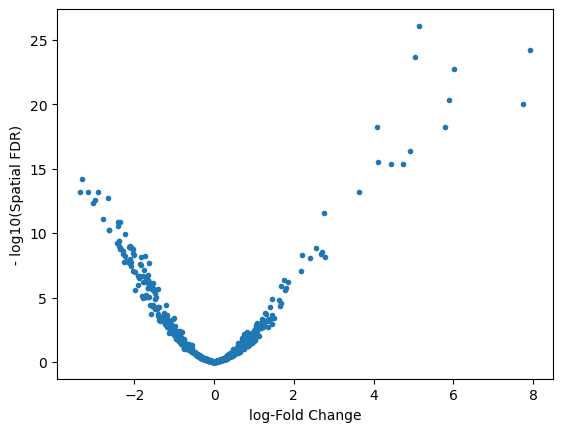

In [22]:
plt.plot(DA_results.logFC, -np.log10(DA_results.SpatialFDR), '.');
plt.xlabel("log-Fold Change");
plt.ylabel("- log10(Spatial FDR)")

## R Visualizations

In [23]:
%%R
milo <- buildNhoodGraph(milo)

In [24]:
%%R 
head(DA_results)

        logFC   logCPM           F       PValue          FDR Nhood   SpatialFDR
  0.75778777 10.34325  5.17105811 2.303242e-02 5.622663e-02     1 5.512044e-02
  0.38400819 10.57437  1.71138918 1.908995e-01 3.030815e-01     2 3.082640e-01
 -1.21777498 10.96944 20.86795035 5.107120e-06 3.804089e-05     3 3.581350e-05
 -1.77098480 10.05236 24.09424597 1.539435e-06 1.202872e-05     4 1.118762e-05
 -0.51363249 10.45782  2.87406707 9.011478e-02 1.739019e-01     5 1.735140e-01
  0.04132601 10.42968  0.01783728 8.937619e-01 9.290484e-01     6 9.264816e-01


In [25]:
%%R 
milo

class: Milo 
dim: 33594 10336 
metadata(0):
assays(1): X
rownames(33594): Xkr4 Gm1992 ... ENSMUSG00000095019 ENSMUSG00000095041
rowData names(0):
colnames(10336): TGTCCGGAGGCAATCC-1@wt AAGTCACCATCCAGAG-1@ko ...
  ACTCGTCCAGCTAAGT-1@wt ACCACAATCGATCAGC-1@ko
colData names(3): sample_pseudo condition cell_type_subset
reducedDimNames(2): PCA UMAP
mainExpName: NULL
altExpNames(0):
nhoods dimensions(2): 10336 797
nhoodCounts dimensions(2): 797 6
nhoodDistances dimension(1): 797
graph names(1): graph
nhoodIndex names(1): 797
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(1): nhoodGraph
nhoodAdjacency dimension(2): 797 797


### Spatial FDR

R[write to console]: Adding nhood effect sizes to neighbourhood graph attributes



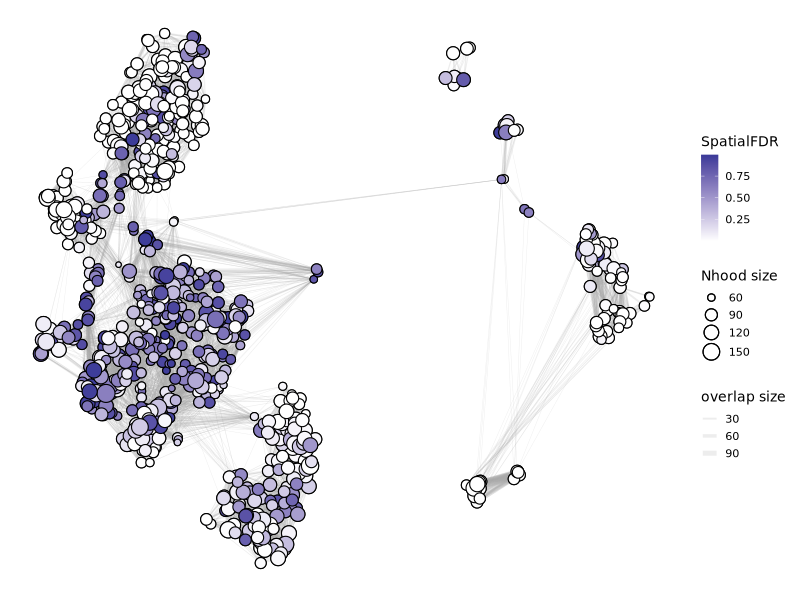

In [26]:
%%R -w 800 -h 600
library(scico)
# color by Spatial_FDR
alpha_val = 1
library(ggplot2)
p1 <- plotNhoodGraphDA(milo, DA_results, res_column = 'SpatialFDR', alpha=alpha_val, 
                 layout='UMAP', size_range = c(2, 8), node_stroke =0.8) 

# Apply berlin to whichever aesthetic is used
#p1 <- p1 + scico::scale_colour_scico(palette = "berlin") +
          #scico::scale_fill_scico(palette = "berlin")

p1

### Log Fold Change

R[write to console]: Adding nhood effect sizes to neighbourhood graph attributes



Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


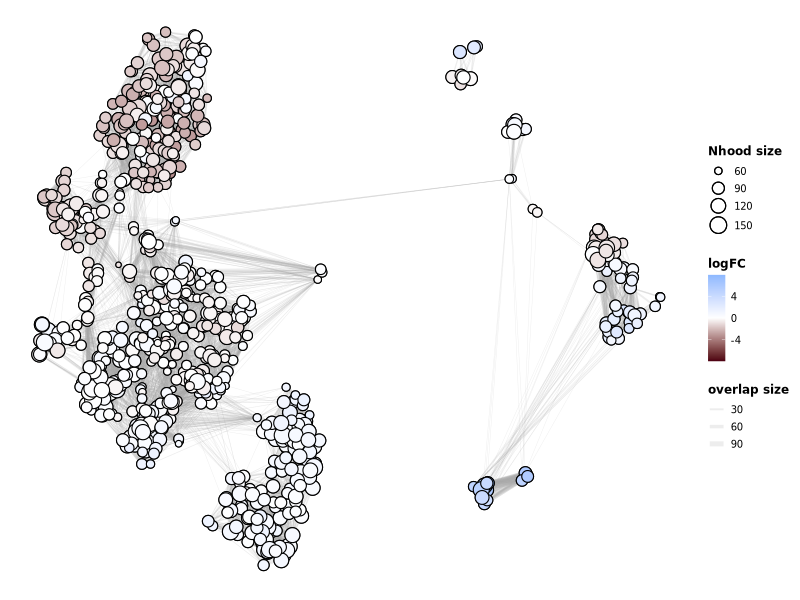

In [27]:
%%R -w 800 -h 600 
# color by log fold change
alpha_val <- 1

# load required libraries
library(ggplot2)

# Define custom colors
young  <- '#4d0011'  
middle <- '#ffffff'  
old    <- '#8eb9ff'   

# Create the MiloR plot
p1 <- plotNhoodGraphDA(
  milo,
  DA_results,
  res_column = 'logFC',
  alpha = alpha_val,
  layout = "UMAP",
  size_range = c(2, 8),
  node_stroke = 0.8
)

# Symmetric color limits around 0
lim_val <- max(abs(DA_results$logFC), na.rm = TRUE)

# Apply custom diverging colorbar (centered at 0)
p1 <- p1 +
  scale_colour_gradient2(
    low = young,
    mid = middle,
    high = old,
    midpoint = 0,
    limits = c(-lim_val, lim_val),
    oob = scales::squish,
    name = "logFC"
  ) +
  scale_fill_gradient2(
    low = young,
    mid = middle,
    high = old,
    midpoint = 0,
    limits = c(-lim_val, lim_val),
    oob = scales::squish,
    name = "logFC"
  ) +
  theme_minimal() +
  theme(
    axis.title = element_blank(),        # remove x/y labels
    axis.text = element_blank(),         # remove tick labels
    axis.ticks = element_blank(),        # remove ticks
    panel.grid = element_blank(),        # remove grid lines
    legend.title = element_text(size = 12, face = "bold"),
    legend.text = element_text(size = 10),
    panel.background = element_rect(fill = "white", colour = NA)
  )

# Display the plot
p1


### Save Figures

In [57]:
%%R -w 600 -h 450 -i figures
library(ggplot2)
library(RColorBrewer)

# Define colors
old    <- '#8eb9ff'
middle <- '#ffffff'  
young  <- '#4d0011'   

alpha_val <- 1

for (j in c('SpatialFDR', 'FDR', 'PValue', 'logFC')) {

    p1 <- plotNhoodGraphDA(
        milo,
        DA_results,
        res_column = j,
        alpha = alpha_val,
        layout = "UMAP",
        size_range = c(2, 8),
        node_stroke = 0.8
    )
    
    if (j == "logFC") {
        # Diverging color scale centered at 0
        lim_val <- max(abs(DA_results$logFC), na.rm = TRUE)
        
        p1 <- p1 +
            scale_colour_gradient2(
                low = young,
                mid = middle,
                high = old,
                midpoint = 0,
                limits = c(-lim_val, lim_val),
                oob = scales::squish,
                name = j
            ) +
            scale_fill_gradient2(
                low = young,
                mid = middle,
                high = old,
                midpoint = 0,
                limits = c(-lim_val, lim_val),
                oob = scales::squish,
                name = j
            )
    } else {
        # Sequential BuGn palette for non-logFC metrics
        p1 <- p1 +
            scale_colour_gradientn(
                colours = RColorBrewer::brewer.pal(9, "BuGn"),
                name = j
            ) +
            scale_fill_gradientn(
                colours = RColorBrewer::brewer.pal(9, "BuGn"),
                name = j
            )
    }

    # Apply clean minimal theme
    p1 <- p1 +
        theme_minimal() +
        theme(
            axis.title = element_blank(),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            panel.grid = element_blank(),
            panel.background = element_rect(fill = "white", colour = NA),
            legend.title = element_text(size = 12, face = "bold"),
            legend.text = element_text(size = 10)
        )

    # Save each figure with transparent background
    ggsave(
        filename = paste0(figures, 'milor_R_', j, '.pdf'),
        plot = p1,
        dpi = 300,
        bg = "transparent"
    )
}

R[write to console]: Adding nhood effect sizes to neighbourhood graph attributes



Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Saving 8.33 x 6.25 in image


R[write to console]: Adding nhood effect sizes to neighbourhood graph attributes



Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Saving 8.33 x 6.25 in image


R[write to console]: Adding nhood effect sizes to neighbourhood graph attributes



Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Saving 8.33 x 6.25 in image


R[write to console]: Adding nhood effect sizes to neighbourhood graph attributes



Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Saving 8.33 x 6.25 in image


## Add Celltype Information

In [29]:
%%R 
DA_results <- annotateNhoods(milo, DA_results, coldata_col = "cell_type_subset")
head(DA_results)

        logFC   logCPM           F       PValue          FDR Nhood   SpatialFDR
  0.75778777 10.34325  5.17105811 2.303242e-02 5.622663e-02     1 5.512044e-02
  0.38400819 10.57437  1.71138918 1.908995e-01 3.030815e-01     2 3.082640e-01
 -1.21777498 10.96944 20.86795035 5.107120e-06 3.804089e-05     3 3.581350e-05
 -1.77098480 10.05236 24.09424597 1.539435e-06 1.202872e-05     4 1.118762e-05
 -0.51363249 10.45782  2.87406707 9.011478e-02 1.739019e-01     5 1.735140e-01
  0.04132601 10.42968  0.01783728 8.937619e-01 9.290484e-01     6 9.264816e-01
            cell_type_subset cell_type_subset_fraction
           11:mimetic(tuft)                 1.0000000
           11:mimetic(tuft)                 1.0000000
                    1:mTEC1                 0.9496403
                     0:cTEC                 1.0000000
                    1:mTEC1                 0.8617021
 5:mimetic(corneocyte-like)                 0.6739130


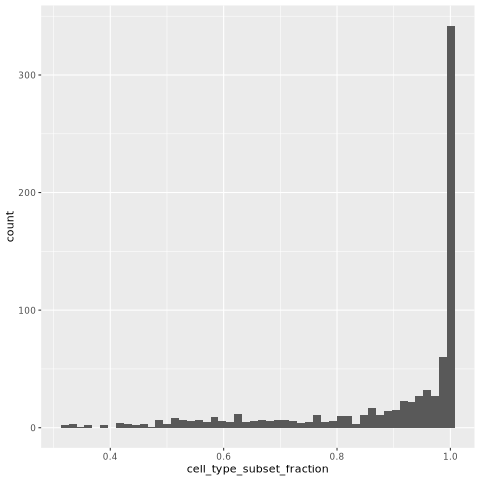

In [31]:
%%R
library(ggplot2)
ggplot(DA_results, aes(cell_type_subset_fraction)) + geom_histogram(bins=50)

In [34]:
%%R -o DA_results
DA_results$Cell_type_subset_milo <- ifelse(DA_results$cell_type_subset_fraction < 0.8, "Mixed", DA_results$cell_type_subset)
head(DA_results)

        logFC   logCPM           F       PValue          FDR Nhood   SpatialFDR
  0.75778777 10.34325  5.17105811 2.303242e-02 5.622663e-02     1 5.512044e-02
  0.38400819 10.57437  1.71138918 1.908995e-01 3.030815e-01     2 3.082640e-01
 -1.21777498 10.96944 20.86795035 5.107120e-06 3.804089e-05     3 3.581350e-05
 -1.77098480 10.05236 24.09424597 1.539435e-06 1.202872e-05     4 1.118762e-05
 -0.51363249 10.45782  2.87406707 9.011478e-02 1.739019e-01     5 1.735140e-01
  0.04132601 10.42968  0.01783728 8.937619e-01 9.290484e-01     6 9.264816e-01
            cell_type_subset cell_type_subset_fraction Cell_type_subset_milo
           11:mimetic(tuft)                 1.0000000      11:mimetic(tuft)
           11:mimetic(tuft)                 1.0000000      11:mimetic(tuft)
                    1:mTEC1                 0.9496403               1:mTEC1
                     0:cTEC                 1.0000000                0:cTEC
                    1:mTEC1                 0.8617021            

In [35]:
DA_results.head()

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,cell_type_subset,cell_type_subset_fraction,Cell_type_subset_milo
1,0.757788,10.343252,5.171058,0.023032,0.056227,1.0,0.055120,11:mimetic(tuft),1.000000,11:mimetic(tuft)
2,0.384008,10.574371,1.711389,0.190900,0.303082,2.0,0.308264,11:mimetic(tuft),1.000000,11:mimetic(tuft)
3,-1.217775,10.969435,20.867950,0.000005,0.000038,3.0,0.000036,1:mTEC1,0.949640,1:mTEC1
4,-1.770985,10.052362,24.094246,0.000002,0.000012,4.0,0.000011,0:cTEC,1.000000,0:cTEC
5,-0.513632,10.457818,2.874067,0.090115,0.173902,5.0,0.173514,1:mTEC1,0.861702,1:mTEC1


### R Beeswarm Plot 

R[write to console]: Converting group_by to factor...



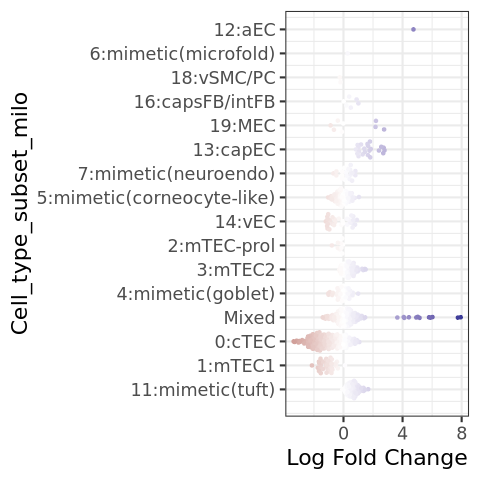

In [37]:
%%R
plotDAbeeswarm(DA_results, group.by = "Cell_type_subset_milo", alpha = 1)

### Python Beeswarm Plots

In [48]:
sorted(adata.obs['cell_type_subset'].unique().to_list())

/tmp/ipykernel_3698212/3302097815.py:1: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  sorted(adata.obs['cell_type_subset'].unique().to_list())


['0:cTEC',
 '10:mimetic(parathyroid)',
 '11:mimetic(tuft)',
 '12:aEC',
 '13:capEC',
 '14:vEC',
 '15:fetalEC',
 '16:capsFB/intFB',
 '17:medFB',
 '18:vSMC/PC',
 '19:MEC',
 '1:mTEC1',
 '2:mTEC-prol',
 '3:mTEC2',
 '4:mimetic(goblet)',
 '5:mimetic(corneocyte-like)',
 '6:mimetic(microfold)',
 '7:mimetic(neuroendo)',
 '8:mimetic(ionocyte)',
 '9:mimetic(ciliated)']

In [39]:
# Define colors
old    = '#3f6048'  
young  = '#e6f0cd'

# Create a continuous colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "old_white_young", [young, old], N=256
)

/tmp/ipykernel_3698212/1776228474.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, color='black', fontsize=12)


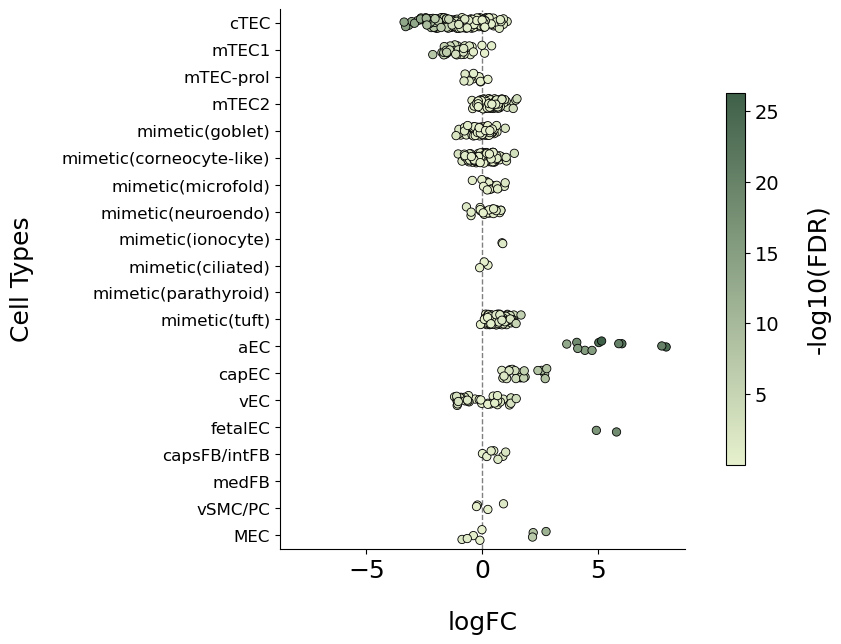

/tmp/ipykernel_3698212/1776228474.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, color='black', fontsize=12)


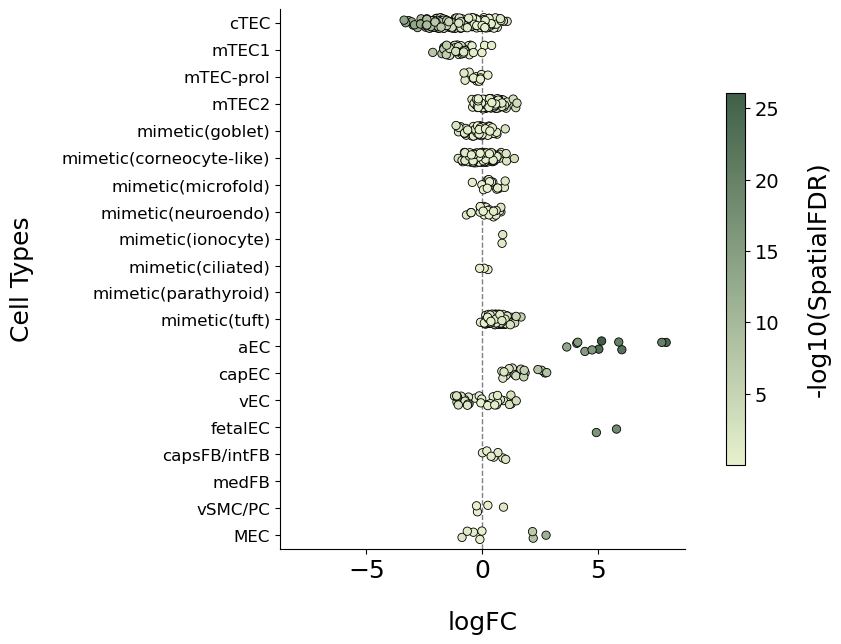

/tmp/ipykernel_3698212/1776228474.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, color='black', fontsize=12)


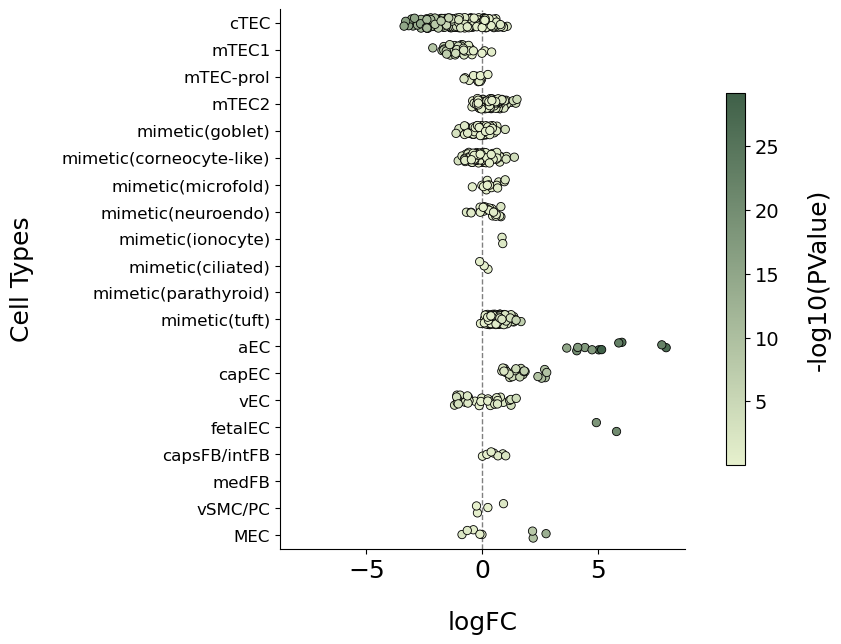

In [58]:
for j, item in enumerate(['FDR', 'SpatialFDR', 'PValue']):
    fig = plt.figure(figsize=(6, 7))
    DA_results['log_' + item] = -np.log10(DA_results[item])
    ax = fig.add_subplot(1, 1, 1)

    order = ['0:cTEC', '1:mTEC1', '2:mTEC-prol', '3:mTEC2', '4:mimetic(goblet)', '5:mimetic(corneocyte-like)',
             '6:mimetic(microfold)', '7:mimetic(neuroendo)','8:mimetic(ionocyte)', '9:mimetic(ciliated)',
            '10:mimetic(parathyroid)','11:mimetic(tuft)', '12:aEC', '13:capEC', '14:vEC', '15:fetalEC', 
             '16:capsFB/intFB', '17:medFB', '18:vSMC/PC', '19:MEC',
            ]


        # Use our custom colormap
    plot = sns.stripplot(
        x='logFC',
        y='cell_type_subset',
        hue='log_' + item,
        data=DA_results,
        size=6,
        palette=custom_cmap,      # custom colormap
        jitter=0.2,
        edgecolor='black',
        linewidth=0.6,
        ax=ax, 
        order=order
    )

    # Center x-axis at 0
    max_abs_logFC = np.nanmax(np.abs(DA_results['logFC']))
    ax.set_xlim(-max_abs_logFC*1.1, max_abs_logFC*1.1)

    # Optional: add a vertical line at 0
    ax.axvline(0, linestyle='--', linewidth=1, color='grey')


    # Remove legend and tidy plot
    plot.get_legend().set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=18)

    labels = [tick.get_text().split(':', 1)[1] for tick in ax.get_yticklabels()]
    ax.set_yticklabels(labels, color='black', fontsize=12)
    
    ax.set_ylabel('Cell Types', fontsize=18, labelpad=20)
    ax.set_xlabel('logFC', fontsize=18, labelpad=20)
    sns.despine()
    ax.grid(False)

    # Create colorbar using the same custom colormap
    normalize = mcolors.Normalize(
        vmin=DA_results['log_' + item].min(),
        vmax=DA_results['log_' + item].max()
    )
    sm = cm.ScalarMappable(norm=normalize, cmap=custom_cmap)
    sm.set_array(DA_results['log_' + item])

    cbar = fig.colorbar(sm,
                        ax=ax,
                        shrink=0.8,     # < 1.0 makes it shorter (along its length)
                        fraction=0.04,  # controls thickness relative to the axis
                        pad=0.09        # distance between axis and colorbar
    )
    cbar.ax.tick_params(labelsize=14)
    cbar.ax.set_ylabel(f'-log10({item})', labelpad=20, rotation=90, fontsize=18)

    
    
    fig.savefig(
        figures + f'milor_swarmplot_colored_by_log_{item}.pdf',
        dpi=300,
        bbox_inches='tight',
        transparent=True
    )

    
    plt.show()

    plt.close(fig)

# Save Data Files

In [55]:
%%R -i file
## Save Milo object to file
saveRDS(milo, file = file.path(file, "dn_milo_object.rds"))

## Load it later
#milo <- readRDS("dn_milo_object.rds")

In [56]:
%%R -i file
write.csv(as.data.frame(DA_results), file = file.path(file, "dn_DA_results.csv"), row.names = FALSE)